# Explorative Analyse: Arbeitsmarkt Regensburg (Jobcenter) — Teil 2: Analyse & Visualisierung

Baut auf den in [`01_Exploration.ipynb`](01_Exploration.ipynb) exportierten CSV-Dateien
(`Data/processed/eckwerte_long.csv`, `Data/processed/kennzahlen_sgb2.csv`) auf.
Falls diese fehlen, `01_Exploration.ipynb` einmal komplett ausführen.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROCESSED_DIR = Path("..") / "Data" / "processed"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv(PROCESSED_DIR / "eckwerte_long.csv")
df["period"] = pd.PeriodIndex(df["period"], freq="M")

kennzahlen = pd.read_csv(PROCESSED_DIR / "kennzahlen_sgb2.csv", index_col="period", parse_dates=["period"])
kennzahlen = kennzahlen.sort_index()

bestand = kennzahlen["Arbeitslose (Bestand)"]
quote = kennzahlen["Arbeitslosenquote (%)"]
lza = kennzahlen["Langzeitarbeitslose"]
uq = kennzahlen["Unterbeschäftigungsquote (%)"]
bg = kennzahlen["Bedarfsgemeinschaften"]
pers = kennzahlen["Personen in BG"]

kennzahlen

,Arbeitslose (Bestand),Arbeitslosenquote (%),Langzeitarbeitslose,Unterbeschäftigungsquote (%),Bedarfsgemeinschaften,Personen in BG,Regelleistungsberechtigte (RLB),Erwerbsfähige Leistungsberechtigte (ELB),Nicht erwerbsfähige Leistungsberechtigte (NEF)
period,,,,,,,,,
2025-04-01,1457.0,1.3,526.0,1.8,2766.959069,5421.148834,5122.424563,3701.239670,1421.184893
2025-05-01,1438.0,1.2,558.0,1.8,2707.556182,5295.629265,4989.629265,3612.418872,1377.210393
2025-06-01,1509.0,1.3,551.0,1.8,2696.605759,5275.539536,4960.102098,3584.217725,1375.884374
2025-07-01,1475.0,1.3,561.0,1.8,2616.920054,5092.808598,4788.461509,3477.798107,1310.663402
2025-08-01,1587.0,1.4,585.0,1.8,2688.060659,5267.867812,4961.929122,3593.655245,1368.273878
2025-09-01,1585.0,1.4,592.0,1.8,2669.283813,5218.350099,4934.149358,3564.447439,1369.701919
2025-10-01,1519.0,1.3,606.0,1.7,2629.348039,5120.198766,4847.485769,3499.340443,1348.145325
2025-11-01,1517.0,1.3,623.0,1.7,2632.776815,5126.678771,4839.956063,3504.915856,1335.040207
2025-12-01,1466.0,1.3,610.0,1.7,2619.193501,5137.270730,4838.074529,3489.353039,1348.721490


## 1. Entwicklung der Arbeitslosigkeit (SGB II)

**SGB II** (Zweites Buch Sozialgesetzbuch) regelt die *Grundsicherung für Arbeitsuchende*
(umgangssprachlich „Bürgergeld", vormals „Hartz IV") und wird von den **Jobcentern** verwaltet
— daher der Fokus dieser Analyse auf den „Rechtskreis SGB II". Abzugrenzen ist das vom
**SGB III** (Arbeitslosenversicherung), für das die Agentur für Arbeit zuständig ist und das
Menschen mit Anspruch auf Arbeitslosengeld I betrifft. Die Berichte weisen beide Rechtskreise
getrennt aus; alle Kennzahlen in dieser Analyse beziehen sich — sofern nicht anders angegeben
— ausschließlich auf SGB II.

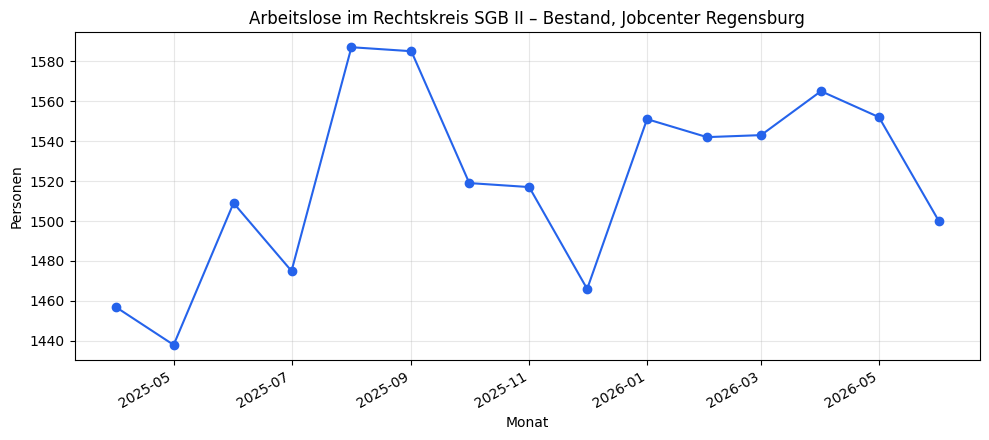

In [2]:
fig, ax = plt.subplots()
ax.plot(bestand.index, bestand.values, marker="o", color="#2563eb")
ax.set_title("Arbeitslose im Rechtskreis SGB II – Bestand, Jobcenter Regensburg")
ax.set_ylabel("Personen")
ax.set_xlabel("Monat")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

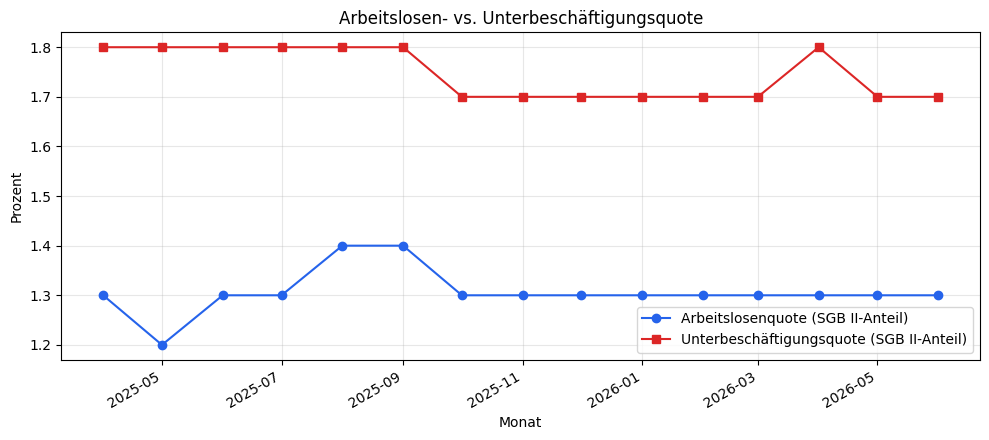

In [3]:
fig, ax = plt.subplots()
ax.plot(quote.index, quote.values, marker="o", label="Arbeitslosenquote (SGB II-Anteil)", color="#2563eb")
ax.plot(uq.index, uq.values, marker="s", label="Unterbeschäftigungsquote (SGB II-Anteil)", color="#dc2626")
ax.set_title("Arbeitslosen- vs. Unterbeschäftigungsquote")
ax.set_ylabel("Prozent")
ax.set_xlabel("Monat")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2. Langzeitarbeitslosigkeit

Anteil der Langzeitarbeitslosen (≥ 1 Jahr arbeitslos) am gesamten Bestand der Arbeitslosen im SGB II.

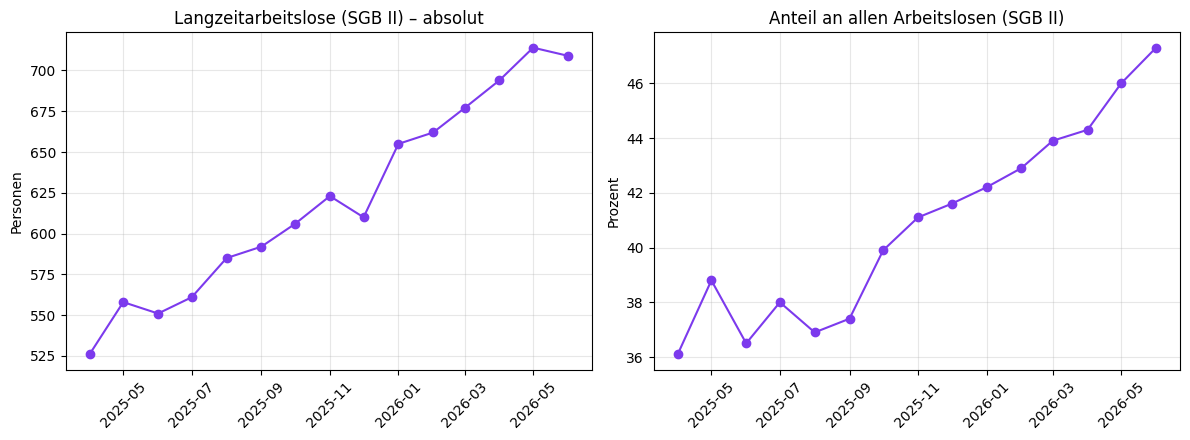

Langzeitarbeitslose: 526 (Apr 2025) -> 709 (Jun 2026)
Anteil am Bestand: 36.1% -> 47.3%


In [4]:
lza_anteil = (lza / bestand * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(lza.index, lza.values, marker="o", color="#7c3aed")
ax1.set_title("Langzeitarbeitslose (SGB II) – absolut")
ax1.set_ylabel("Personen")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(lza_anteil.index, lza_anteil.values, marker="o", color="#7c3aed")
ax2.set_title("Anteil an allen Arbeitslosen (SGB II)")
ax2.set_ylabel("Prozent")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Langzeitarbeitslose: {lza.iloc[0]:.0f} ({lza.index[0]:%b %Y}) -> {lza.iloc[-1]:.0f} ({lza.index[-1]:%b %Y})")
print(f"Anteil am Bestand: {lza_anteil.iloc[0]:.1f}% -> {lza_anteil.iloc[-1]:.1f}%")

## 3. Grundsicherung: Bedarfsgemeinschaften und Personen im Leistungsbezug

## 4. Kennzahlen im Vergleich (indexiert)

Die vier Kernkennzahlen haben sehr unterschiedliche Größenordnungen (500 bis 5.000+), daher werden sie hier auf den ersten Berichtsmonat indexiert (= 100 gesetzt), um ihre relative Entwicklung in einem Diagramm vergleichbar zu machen.

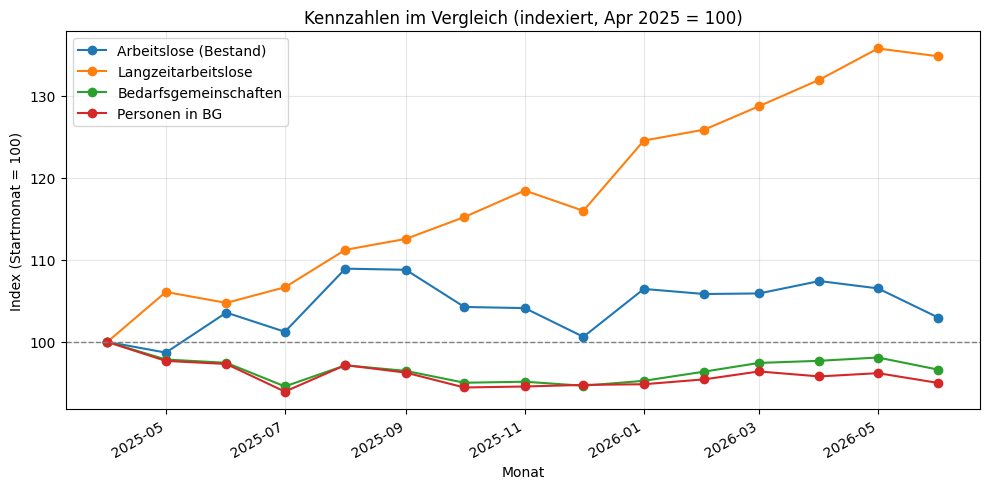

In [5]:
vergleich_spalten = ["Arbeitslose (Bestand)", "Langzeitarbeitslose", "Bedarfsgemeinschaften", "Personen in BG"]
indexiert = kennzahlen[vergleich_spalten] / kennzahlen[vergleich_spalten].iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 5))
for spalte in vergleich_spalten:
    ax.plot(indexiert.index, indexiert[spalte], marker="o", label=spalte)
ax.axhline(100, color="grey", linestyle="--", linewidth=1)
ax.set_title(f"Kennzahlen im Vergleich (indexiert, {indexiert.index[0]:%b %Y} = 100)")
ax.set_ylabel("Index (Startmonat = 100)")
ax.set_xlabel("Monat")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

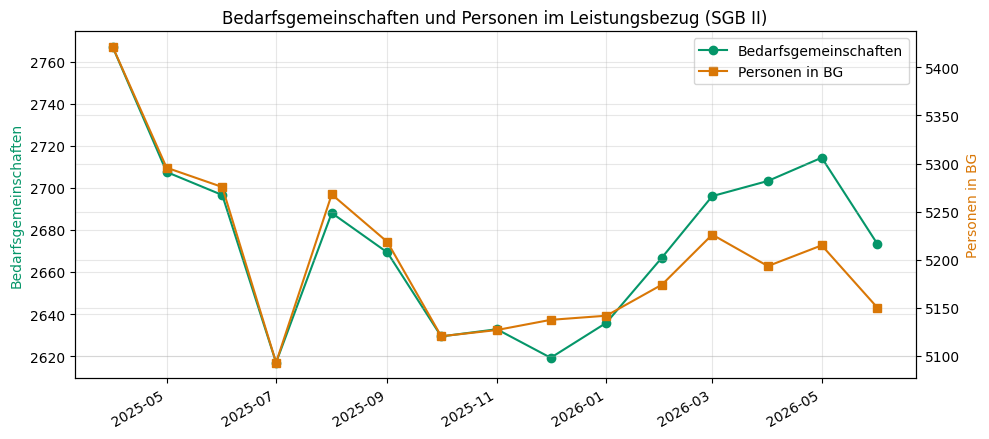

In [6]:
fig, ax = plt.subplots()
ax.plot(bg.index, bg.values, marker="o", label="Bedarfsgemeinschaften", color="#059669")
ax2 = ax.twinx()
ax2.plot(pers.index, pers.values, marker="s", label="Personen in BG", color="#d97706")

ax.set_title("Bedarfsgemeinschaften und Personen im Leistungsbezug (SGB II)")
ax.set_ylabel("Bedarfsgemeinschaften", color="#059669")
ax2.set_ylabel("Personen in BG", color="#d97706")
fig.autofmt_xdate()

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

## 5. Altersstruktur und Geschlecht (letzter Berichtsmonat)

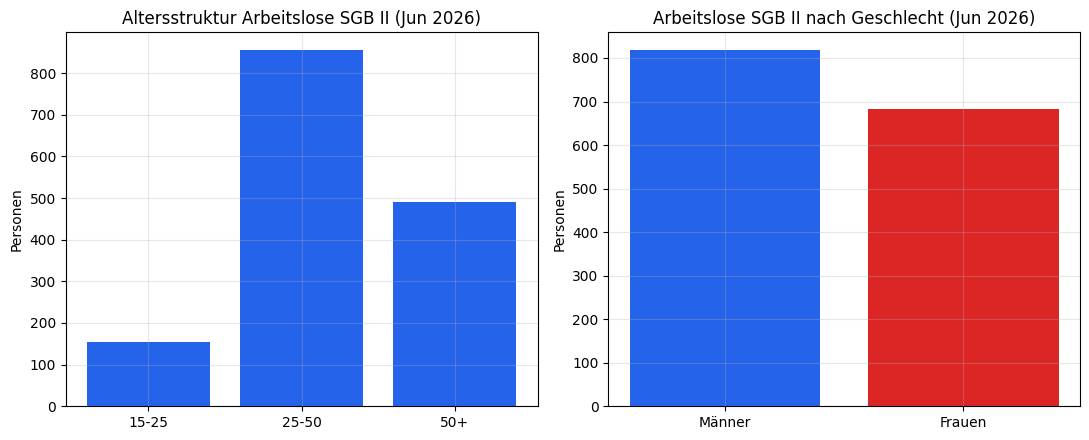

In [7]:
letzter_monat = df["period"].max()
letzter_monat_label = letzter_monat.strftime("%b %Y")
snap = df[(df["period"] == letzter_monat) & (df["kategorie"] == "Arbeitslose")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

alter_labels = ["15 bis unter 25 Jahre", "25 bis unter 50 Jahre", "50 Jahre und älter"]
alter_werte = [snap.set_index("merkmal").loc[l, "sgb2"] for l in alter_labels]
ax1.bar(["15-25", "25-50", "50+"], alter_werte, color="#2563eb")
ax1.set_title(f"Altersstruktur Arbeitslose SGB II ({letzter_monat_label})")
ax1.set_ylabel("Personen")

geschlecht_labels = ["Männer", "Frauen"]
geschlecht_werte = [snap.set_index("merkmal").loc[l, "sgb2"] for l in geschlecht_labels]
ax2.bar(geschlecht_labels, geschlecht_werte, color=["#2563eb", "#dc2626"])
ax2.set_title(f"Arbeitslose SGB II nach Geschlecht ({letzter_monat_label})")
ax2.set_ylabel("Personen")

plt.tight_layout()
plt.show()

## 6. Veränderung zum Vormonat und zum Vorjahresmonat

In [8]:
def veraenderung(series: pd.Series) -> pd.Series:
    letzter = series.iloc[-1]
    vormonat = series.iloc[-2]
    vorjahr = series.iloc[-13] if len(series) >= 13 else None
    return pd.Series({
        "aktuell": letzter,
        "Vormonat abs.": letzter - vormonat,
        "Vormonat %": round((letzter - vormonat) / vormonat * 100, 1),
        "Vorjahresmonat abs.": (letzter - vorjahr) if vorjahr is not None else None,
        "Vorjahresmonat %": round((letzter - vorjahr) / vorjahr * 100, 1) if vorjahr is not None else None,
    })


changes = pd.DataFrame({
    "Arbeitslose (Bestand)": veraenderung(bestand),
    "Langzeitarbeitslose": veraenderung(lza),
    "Bedarfsgemeinschaften": veraenderung(bg),
    "Personen in BG": veraenderung(pers),
}).T
changes

,aktuell,Vormonat abs.,Vormonat %,Vorjahresmonat abs.,Vorjahresmonat %
Arbeitslose (Bestand),1500.000000,-52.000000,-3.4,-9.000000,-0.6
Langzeitarbeitslose,709.000000,-5.000000,-0.7,158.000000,28.7
Bedarfsgemeinschaften,2673.353373,-41.012939,-1.5,-23.252386,-0.9
Personen in BG,5149.986005,-64.836537,-1.2,-125.553531,-2.4


## 7. Zusammenfassung

Auf Basis der 15 Monatsberichte (April 2025 – Juni 2026) für das Jobcenter Regensburg (Rechtskreis SGB II):

- **Arbeitslose (Bestand):** von 1.457 (Apr 2025) auf 1.500 (Jun 2026) – leicht gestiegen, mit einem
  Zwischenhoch von 1.587 im August 2025 und einem Tiefpunkt von 1.438 im Mai 2025.
- **Arbeitslosenquote:** schwankt eng zwischen 1,2 % und 1,4 %, aktuell wieder bei 1,3 % – insgesamt stabil.
- **Langzeitarbeitslosigkeit:** deutlichster Trend im Datensatz – von 526 auf 709 Personen (+ rund 35 %),
  mit einem Höchststand von 714 im Mai 2026. Der Anteil an allen Arbeitslosen ist damit spürbar gestiegen.
- **Bedarfsgemeinschaften / Personen im Leistungsbezug:** beide Kennzahlen sind rückläufig
  (BG: 2.767 → 2.673; Personen in BG: 5.421 → 5.150, jeweils ca. −5 %).

**Interpretation:** Während die reine Arbeitslosenzahl und -quote im Beobachtungszeitraum relativ stabil
geblieben sind, hat sich die Langzeitarbeitslosigkeit spürbar verschärft – ein Hinweis darauf, dass es für
einen wachsenden Teil der Betroffenen schwerer wird, aus der Arbeitslosigkeit herauszukommen, auch wenn die
Zahl der Bedarfsgemeinschaften insgesamt sinkt.